In [2]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
import PIL
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [3]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url,  cache_dir='.', untar=True)
# cache_dir indicates where to download data. I specified . which means current directory
# untar true will unzip it

In [4]:
data_dir

'.\\datasets\\flower_photos'

In [5]:
import pathlib
data_dir = pathlib.Path(data_dir)
data_dir

WindowsPath('datasets/flower_photos')

In [6]:
list(data_dir.glob('**/*.jpg'))[:5]

[WindowsPath('datasets/flower_photos/flower_photos/daisy/100080576_f52e8ee070_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/daisy/10140303196_b88d3d6cec.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/daisy/10172379554_b296050f82_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/daisy/10172567486_2748826a8b.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/daisy/10172636503_21bededa75_n.jpg')]

In [7]:
image_count = len(list(data_dir.glob('**/*.jpg')))
print(image_count)

3670


In [8]:
roses = list(data_dir.glob('**/roses/*'))
roses[:5]

[WindowsPath('datasets/flower_photos/flower_photos/roses/10090824183_d02c613f10_m.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/102501987_3cdb8e5394_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/10503217854_e66a804309.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/10894627425_ec76bbc757_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/110472418_87b6a3aa98_m.jpg')]

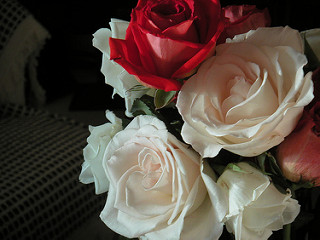

In [9]:
PIL.Image.open(str(roses[1]))

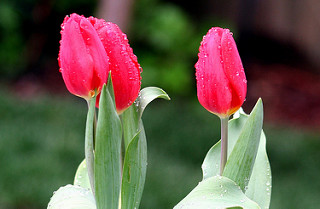

In [10]:
tulips = list(data_dir.glob('**/tulips/*'))
PIL.Image.open(str(tulips[0]))
                        

In [11]:
flowers_images_dict = {
    'roses': list(data_dir.glob('**/roses/*')),
    'daisy': list(data_dir.glob('**/daisy/*')),
    'dandelion': list(data_dir.glob('**/dandelion/*')),
    'sunflowers': list(data_dir.glob('**/sunflowers/*')),
    'tulips': list(data_dir.glob('**/tulips/*')),
}

In [12]:
flowers_label_dict = {
    'roses': 0,
    'daisy': 1,
    'dandelion': 2,
    'sunflowers': 3,
    'tulips': 4,
}

In [13]:
# Use the key 'roses' instead of '**/roses/*'
flowers_images_dict['roses'][:5]

[WindowsPath('datasets/flower_photos/flower_photos/roses/10090824183_d02c613f10_m.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/102501987_3cdb8e5394_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/10503217854_e66a804309.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/10894627425_ec76bbc757_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/110472418_87b6a3aa98_m.jpg')]

In [14]:
str(flowers_images_dict['roses'][:1])

"[WindowsPath('datasets/flower_photos/flower_photos/roses/10090824183_d02c613f10_m.jpg')]"

In [15]:
img = cv2.imread(str(flowers_images_dict['roses'][0]))

In [16]:
img.shape

(240, 179, 3)

In [17]:
cv2.resize(img,(180,180)).shape

(180, 180, 3)

In [18]:
x,y = [],[]
for flowers_name, images in flowers_images_dict.items():
    for image in images:
        img = cv2.imread(str(image))
        resized_img = cv2.resize(img,(180,180))
        x.append(resized_img)
        y.append(flowers_label_dict[flowers_name])

In [19]:
x = np.array(x)
y = np.array(y)

In [20]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, random_state=0)

In [21]:
X_train_scaled = X_train / 255
X_test_scaled = X_test / 255

In [22]:

num_classes = 5
model = Sequential([
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])
              
model.fit(X_train_scaled, y_train, epochs=5)             

Epoch 1/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 47s 493ms/step - accuracy: 0.4339 - loss: 1.3108
Epoch 2/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 79s 465ms/step - accuracy: 0.6079 - loss: 1.0083
Epoch 3/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 41s 463ms/step - accuracy: 0.6813 - loss: 0.8446
Epoch 4/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 41s 477ms/step - accuracy: 0.7529 - loss: 0.6510
Epoch 5/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 41s 478ms/step - accuracy: 0.8481 - loss: 0.4358


In [23]:
model.evaluate(X_test_scaled,y_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 122ms/step - accuracy: 0.6155 - loss: 1.1091


[1.1091265678405762, 0.6154683828353882]

In [24]:
predictions = model.predict(X_test_scaled)
predictions

29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 144ms/step


array([[ 2.6860716 ,  3.4659863 ,  2.754967  , -5.3693085 , -1.729051  ],
       [ 4.0071807 , -0.1088006 , -4.8565807 , -3.2990892 ,  4.8683276 ],
       [-0.1969134 ,  0.60695666,  5.5099273 , -4.1746163 , -0.850566  ],
       ...,
       [ 0.8901011 , -1.515714  , -1.5629852 ,  2.2155375 ,  0.3925706 ],
       [ 1.6596601 , -0.5906251 ,  1.1139443 , -1.1241305 ,  1.4484597 ],
       [ 0.39364028, -7.0822225 ,  0.72619957,  2.0864964 ,  1.3768574 ]],
      shape=(918, 5), dtype=float32)

In [25]:
score = tf.nn.softmax(predictions[0])

In [26]:
np.argmax(score)

np.int64(1)

In [27]:
y_test[0]

np.int64(1)

In [28]:
# Define the image dimensions first
img_height = 180
img_width = 180

# Updated data augmentation sequence without 'experimental'
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal", input_shape=(img_height, img_width, 3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

C:\Users\niran\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


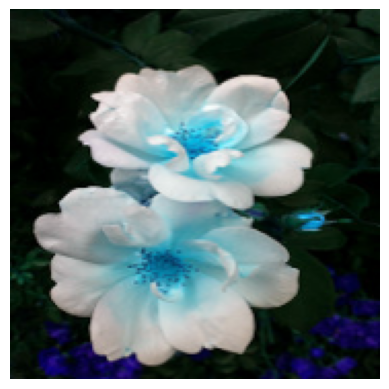

In [29]:
plt.axis('off')
plt.imshow(x[0])

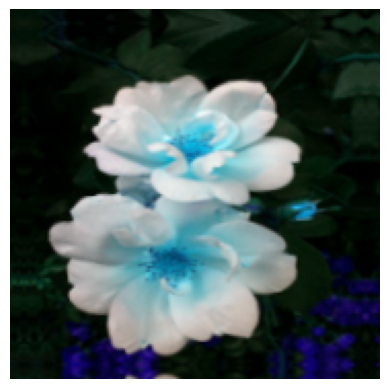

In [30]:
plt.axis('off')
plt.imshow(data_augmentation(x)[0].numpy().astype("uint8"))

In [31]:
num_classes = 5
model = Sequential([
    data_augmentation,
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes)
])
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])
              
model.fit(X_train_scaled, y_train, epochs=30)    

Epoch 1/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 61s 655ms/step - accuracy: 0.3441 - loss: 1.6464
Epoch 2/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 56s 644ms/step - accuracy: 0.5491 - loss: 1.1214
Epoch 3/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 56s 651ms/step - accuracy: 0.6188 - loss: 0.9942
Epoch 4/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 56s 656ms/step - accuracy: 0.6439 - loss: 0.9196
Epoch 5/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 55s 636ms/step - accuracy: 0.6646 - loss: 0.8773
Epoch 6/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 56s 647ms/step - accuracy: 0.6908 - loss: 0.8041
Epoch 7/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 81s 632ms/step - accuracy: 0.7057 - loss: 0.7769
Epoch 8/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 82s 629ms/step - accuracy: 0.7264 - loss: 0.7268
Epoch 9/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 82s 628ms/step - accuracy: 0.7286 - loss: 0.7099
Epoch 10/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 83s 640ms/step - accuracy: 0.7347 - loss: 0.6847
Epoch 11/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 55s 643ms/step - accuracy: 0.7576 - loss: 0.6393
Epoch 12/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 37

In [32]:
model.evaluate(X_test_scaled,y_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.7255 - loss: 0.9615


[0.9614938497543335, 0.7254902124404907]

In [33]:
# 1. Get raw predictions (logits) for the training data
train_predictions = model.predict(X_train_scaled)

# 2. Convert logits to actual predicted class indices
# (Takes the index of the highest score for each image)
train_predicted_labels = np.argmax(train_predictions, axis=1)

# 3. Print the first 10 true labels vs predicted labels to compare
print("True Labels:     ", y_train[:10])
print("Predicted Labels:", train_predicted_labels[:10])

86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step
True Labels:      [2 0 1 2 4 0 0 3 3 4]
Predicted Labels: [1 0 1 2 4 0 0 3 3 0]


In [37]:
import tensorflow as tf
from tensorflow.keras import layers, Sequential
IMAGE_SHAPE  = (180,180,3)

base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMAGE_SHAPE,
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

C:\Users\niran\AppData\Local\Temp\ipykernel_18528\2334626559.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


In [38]:
num_classes = 5
model_tf = Sequential([
    data_augmentation,
    layers.Lambda(lambda x: (x * 2.0) - 1.0),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.1),
    layers.Dense(num_classes)
])
model_tf.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

# Train for fewer epochs (Transfer learning converges much faster!)
model_tf.fit(X_train_scaled, y_train, epochs=10)

Epoch 1/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 48s 462ms/step - accuracy: 0.6359 - loss: 0.9726
Epoch 2/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 74s 862ms/step - accuracy: 0.7911 - loss: 0.5877
Epoch 3/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 82s 956ms/step - accuracy: 0.8147 - loss: 0.5146
Epoch 4/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 83s 965ms/step - accuracy: 0.8270 - loss: 0.4745
Epoch 5/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 82s 955ms/step - accuracy: 0.8438 - loss: 0.4281
Epoch 6/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 80s 930ms/step - accuracy: 0.8586 - loss: 0.4025
Epoch 7/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 79s 900ms/step - accuracy: 0.8645 - loss: 0.3901
Epoch 8/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 77s 891ms/step - accuracy: 0.8677 - loss: 0.3741
Epoch 9/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 76s 887ms/step - accuracy: 0.8805 - loss: 0.3457
Epoch 10/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 82s 890ms/step - accuracy: 0.8852 - loss: 0.3383


In [39]:
model_tf.evaluate(X_test_scaled,y_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 22s 697ms/step - accuracy: 0.8595 - loss: 0.4088


[0.4088212549686432, 0.8594771027565002]

In [40]:
# 1. Get raw predictions (logits) for the training data
train_prediction = model_tf.predict(X_train_scaled)

# 2. Convert logits to actual predicted class indices
# (Takes the index of the highest score for each image)
train_predicted_label = np.argmax(train_prediction, axis=1)

# 3. Print the first 10 true labels vs predicted labels to compare
print("True Labels:     ", y_train[:10])
print("Predicted Labels:", train_predicted_label[:10])

86/86 ━━━━━━━━━━━━━━━━━━━━ 63s 724ms/step
True Labels:      [2 0 1 2 4 0 0 3 3 4]
Predicted Labels: [2 4 0 2 4 0 0 3 3 4]


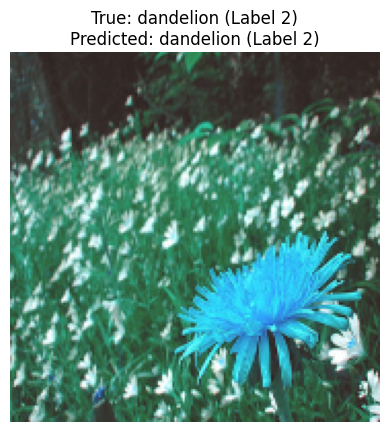

In [42]:

class_names = ['roses', 'daisy', 'dandelion', 'sunflowers', 'tulips']

index = 0

# 3. Get the true and predicted label numbers
true_label = y_train[index]
predicted_label = train_predicted_label[index]

plt.imshow(X_train[index])
plt.title(f"True: {class_names[true_label]} (Label {true_label})\n"
          f"Predicted: {class_names[predicted_label]} (Label {predicted_label})")
plt.axis('off')
plt.show()